In [1]:
import pandas as pd
df = pd.read_csv("C:\\Users\\midof\\OneDrive\\Desktop\\INeuron\\CNN\\PidRayDataset\\SPXray\\SPXray\\DatasetSPXray_classification_dataset.csv")
df

,Image_Path,Label,Split
0,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Baton,train
1,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Baton,train
2,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Baton,train
3,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Baton,train
4,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Baton,train
...,...,...,...
11494,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Wrench,test
11495,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Wrench,test
11496,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Wrench,test
11497,C:\Users\midof\OneDrive\Desktop\INeuron\CNN\Pi...,Wrench,test


In [2]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

In [3]:
# Second split: split the remaining 20% into 10% validation and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validation: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 9199 (80.0%)
Validation: 1150 (10.0%)
Test: 1150 (10.0%)


C:\Users\midof\AppData\Local\Temp\ipykernel_12096\3437333589.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="Label", palette="viridis", ax=ax)


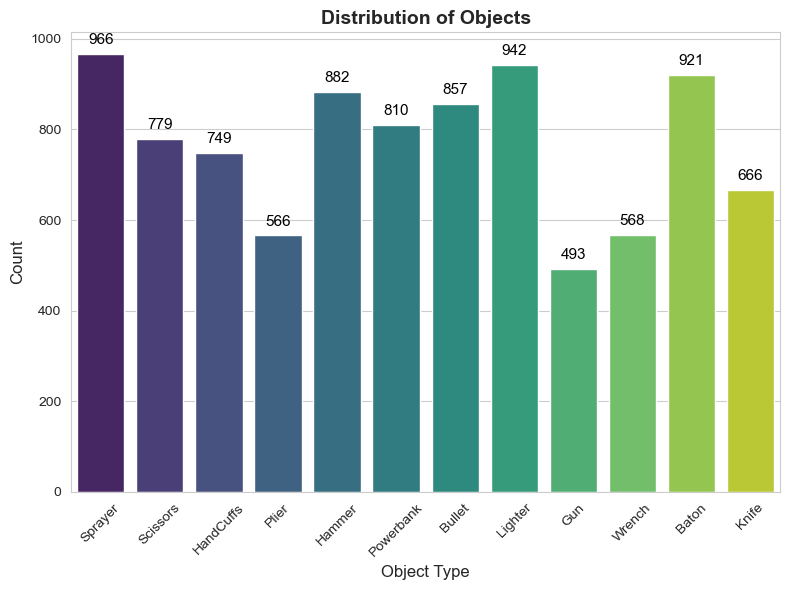

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 6))

sns.countplot(data=train_df, x="Label", palette="viridis", ax=ax)

ax.set_title("Distribution of Objects", fontsize=14, fontweight='bold')
ax.set_xlabel("Object Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.utils import resample

categories = train_df['Label'].unique()
max_count = train_df['Label'].value_counts().max()
df_balanced = pd.DataFrame()

for category in categories:
    df_category = df[df['Label'] == category]
    df_category_resampled = resample(df_category, replace=True, n_samples=max_count, random_state=42)
    df_balanced = pd.concat([df_balanced, df_category_resampled], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanced['Label'].value_counts())
train_df = df_balanced

Label
Gun          966
Hammer       966
Bullet       966
Scissors     966
Lighter      966
Knife        966
Sprayer      966
Baton        966
Powerbank    966
Plier        966
Wrench       966
HandCuffs    966
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [7]:
# EfficientNetB0

IMG_SIZE = 128
def load_images(df):
    X = []

    for path in df["Image_Path"]:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

    return np.array(X, dtype=np.float32)

In [ ]:
X_train = load_images(train_df)
# one hot encoding labels
y_train = pd.get_dummies(train_df["Label"]).values
label_names = pd.get_dummies(train_df["Label"]).columns

In [ ]:
x_val = load_images(val_df)
# one hot encoding labels
y_val = pd.get_dummies(val_df["Label"]).values
label_names = pd.get_dummies(val_df["Label"]).columns

In [ ]:
x_test = load_images(test_df)
# one hot encoding labels
y_test = pd.get_dummies(test_df["Label"]).values
label_names = pd.get_dummies(test_df["Label"]).columns

In [ ]:
print(X_train.shape)
print(y_train.shape)

In [ ]:
print(x_val.shape)
print(y_val.shape)

In [ ]:
print(x_test.shape)
print(y_test.shape)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)), MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'), MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'), MaxPooling2D(2,2),

    Flatten(), Dense(128, activation='relu'), Dropout(0.5),

    Dense(12, activation='softmax')
])

In [ ]:
cnn_model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy']) 
cnn_model.summary()

In [ ]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss", verbose=1) 

CKPT_path = "C:\\Users\\midof\\OneDrive\\Desktop\\INeuron\\CNN\\PidRayDataset\\SPXray\\SPXray\\Dataset\\Custom_Model\\model_custom.keras" #The last best model saved as an h5

checkpointing_cb = tf.keras.callbacks.ModelCheckpoint(CKPT_path, monitor="val_loss", save_best_only=True, verbose=1)

#Now let create a list and pass those functionality in the list
CALLBACKS_LIST = [early_stopping_cb, checkpointing_cb]

In [ ]:
model_history = cnn_model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(x_val, y_val), callbacks=CALLBACKS_LIST)

# PreTrained Model

In [ ]:
import pandas as pd
df = pd.read_csv("C:\\Users\\midof\\OneDrive\\Desktop\\INeuron\\CNN\\PidRayDataset\\SPXray\\SPXray\\DatasetSPXray_classification_dataset.csv")
df

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

In [ ]:
# Second split: split the remaining 20% into 10% validation and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validation: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

In [ ]:
from sklearn.utils import resample

categories = train_df['Label'].unique()
max_count = train_df['Label'].value_counts().max()
df_balanced = pd.DataFrame()

for category in categories:
    df_category = df[df['Label'] == category]
    df_category_resampled = resample(df_category, replace=True, n_samples=max_count, random_state=42)
    df_balanced = pd.concat([df_balanced, df_category_resampled], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_balanced['Label'].value_counts())
train_df = df_balanced

In [ ]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
# EfficientNetB0

IMG_SIZE = 224
def load_images(df):
    X = []

    for path in df["Image_Path"]:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

    return np.array(X, dtype=np.float32)

In [ ]:
X_train = load_images(train_df)
# one hot encoding labels
y_train = pd.get_dummies(train_df["Label"]).values
label_names = pd.get_dummies(train_df["Label"]).columns

In [ ]:
x_val = load_images(val_df)
# one hot encoding labels
y_val = pd.get_dummies(val_df["Label"]).values
label_names = pd.get_dummies(val_df["Label"]).columns

In [ ]:
x_test = load_images(test_df)
# one hot encoding labels
y_test = pd.get_dummies(test_df["Label"]).values
label_names = pd.get_dummies(test_df["Label"]).columns

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (Dense, Flatten, GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

In [ ]:
# freeze base model (RESNET 50)
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
#base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
output = Dense(12, activation='softmax')(x)

model = Model(base_model.input, output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

In [ ]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss", verbose=1) 

In [ ]:
CKPT_path = "C:\\Users\\midof\\OneDrive\\Desktop\\INeuron\\CNN\\PidRayDataset\\SPXray\\SPXray\\Dataset\\PreTrained-Model\\model_ckpt.keras" #The last best model saved as an h5

checkpointing_cb = tf.keras.callbacks.ModelCheckpoint(CKPT_path, monitor="val_loss", save_best_only=True, verbose=1)

In [ ]:
#Now let create a list and pass those functionality in the list
CALLBACKS_LIST = [early_stopping_cb, checkpointing_cb]

In [ ]:
model_history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_data=(x_val, y_val), callbacks=CALLBACKS_LIST)

In [ ]:
all_labels = pd.get_dummies(df["Label"])

y_train = all_labels.loc[train_df.index].values
y_val   = all_labels.loc[val_df.index].values
y_test  = all_labels.loc[test_df.index].values

label_names = all_labels.columns
num_classes = len(label_names)